# Absolute locations — HYPOINVERSE vs HypoSVI vs KMA — gwangyang_stp

Three absolute hypocentre estimates for the **same events, same PhaseNet+ picks**:

| | locator | uncertainty reported |
|---|---|---|
| **HYPOINVERSE** (ff) | Fortran `hyp1.40`, `kim1983` | formal least-squares covariance from the `.prt` |
| **HypoSVI** (svi) | EikoNet + SVGD, `kim1983` | posterior (SVGD particle cloud) |
| **KMA** | KMA operational catalog | none published |

**Uncertainty convention (so the error bars are comparable):**
- HYPOINVERSE `.sum` **ERH/ERZ are 1-sigma** (~68% per coord). Here we draw the **95% joint**
  horizontal ellipse from the full `.prt` covariance (axes = 2.448 x 1-sigma) and **95%** depth
  bars (1.96 x sigma_z). (Established in the Ulsan-fault study; see `pocketquake.hyp_prt`.)
- HypoSVI ERH/ERZ are already **posterior 95%** half-widths — plotted as-is.
- KMA has no uncertainty — plotted as a bare marker.

Everything is in **Cartesian km** (East / North / Depth), centred on the HYPOINVERSE centroid so
the absolute offsets between the three are visible.

In [1]:
%matplotlib inline
import os, sys
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "..")))         # eq-cycle root
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "..", "..", "..")))  # repo root (pocketquake)
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from pyproj import Proj
from IPython.display import display

from pipeline import config
from pipeline.core import sumio, waveforms
from pocketquake import hyp_prt
from glob import glob

CLUSTER  = "gwangyang_stp"
VELMODEL = "kim1983"
SVI_SUB  = "hyposvi_run"

cfg     = config.load_cluster(CLUSTER)
cfg_svi = config.tune(cfg, output_root=os.path.join(cfg.output_root, SVI_SUB))
print(f"{cfg.region}:  ff(HYPOINVERSE)={config.sum_file(cfg, VELMODEL)}")
print(f"            svi(HypoSVI)  ={config.sum_file(cfg_svi, VELMODEL)}")

_PJ = Proj("+proj=utm +zone=52 +ellps=WGS84 +units=km")   # local Cartesian km

# id (cuspid 200000+idx) -> event_id (UTC dir name) -> KMA catalog row.
_dirs = sorted(glob(os.path.join(config.waveforms_dir(cfg), "20*")))
id2eid = {cfg.cuspid_offset + i: os.path.basename(d) for i, d in enumerate(_dirs)}
_kma = {e["event_id"]: e for e in waveforms.load_catalog(cfg)}
print(f"{len(_dirs)} event dirs, {len(_kma)} catalog rows")

Gwangyang_stp:  ff(HYPOINVERSE)=/home/msseo/works/15.PocketQuake/external/korea-cluster-relocation/pipeline/runs/gwangyang_stp/1.HypoInv/kim1983/Gwangyang_stp.sum
            svi(HypoSVI)  =/home/msseo/works/15.PocketQuake/external/korea-cluster-relocation/pipeline/runs/gwangyang_stp/hyposvi_run/1.HypoInv/kim1983/Gwangyang_stp.sum
6 event dirs, 11 catalog rows


In [2]:
# --- load the three sources, indexed by cuspid id ---
HINV = sumio.read_sum(config.sum_file(cfg, VELMODEL)).set_index("id")
SVI  = sumio.read_sum(config.sum_file(cfg_svi, VELMODEL)).set_index("id")

# HYPOINVERSE full covariance from the .prt (for 95% ellipses). Matched to .sum by id.
prt_path = config.prt_file(cfg, VELMODEL)
PRT = hyp_prt.parse_prt(prt_path).set_index("id") if os.path.exists(prt_path) else pd.DataFrame()
# HypoSVI posterior covariance from the SVGD particle cloud (sidecar written by hyposvi_backend),
# giving a proper ORIENTED posterior ellipse (the .sum only carries scalar ERH/ERZ).
svicov_path = os.path.join(config.velmodel_dir(cfg_svi, VELMODEL), f"{cfg.region}.svicov.csv")
SVICOV = pd.read_csv(svicov_path).set_index("id") if os.path.exists(svicov_path) else pd.DataFrame()
print(f"HYPOINVERSE located: {len(HINV)} | HypoSVI located: {len(SVI)} | "
      f".prt cov: {len(PRT)} | SVGD posterior cov: {len(SVICOV)}")

def kma_row(i):
    e = _kma.get(id2eid.get(i))
    return None if e is None else e

ids = [i for i in sorted(set(HINV.index) & set(SVI.index))]
print(f"matched HINV & SVI: {len(ids)} events; with KMA: {sum(kma_row(i) is not None for i in ids)}")

HYPOINVERSE located: 6 | HypoSVI located: 6 | .prt cov: 6 | SVGD posterior cov: 6
matched HINV & SVI: 6 events; with KMA: 6


In [3]:
def cart(lon, lat):           # -> (E_km, N_km)
    return _PJ(lon, lat)

def rows_cart(R, ids):        # E, N, Depth(km) arrays for a .sum frame
    E = np.array([cart(R.loc[i].lon, R.loc[i].lat)[0] for i in ids])
    N = np.array([cart(R.loc[i].lon, R.loc[i].lat)[1] for i in ids])
    Z = np.array([R.loc[i].depth for i in ids])
    return E, N, Z

EH, NH, ZH = rows_cart(HINV, ids)
ES, NS, ZS = rows_cart(SVI,  ids)
_km = [(cart(e["lon"], e["lat"]) if e else (np.nan, np.nan)) + (e["depth"] if e else np.nan,)
       for e in (kma_row(i) for i in ids)]
EK = np.array([c[0] for c in _km]); NK = np.array([c[1] for c in _km]); ZK = np.array([c[2] for c in _km])

# centre on the HYPOINVERSE centroid (drop NaN KMA from the centroid)
c0 = np.array([EH.mean(), NH.mean(), ZH.mean()])
def ctr(E, N, Z): return E - c0[0], N - c0[1], Z - c0[2]
eH, nH, zH = ctr(EH, NH, ZH); eS, nS, zS = ctr(ES, NS, ZS); eK, nK, zK = ctr(EK, NK, ZK)

## 1. Map + cross-sections (95% joint covariance ellipses)

Every panel draws a true **2-D 95% joint covariance ellipse** (k = √χ²₂,₀.₉₅ = 2.448) for each
locator — so orientation and the depth↔horizontal trade-off are visible, not just axis lengths:
- **Blue = HYPOINVERSE** — formal least-squares covariance from the `.prt` (its scalar ERH/ERZ
  are 1-sigma; here we use the full covariance matrix at 95% joint).
- **Red = HypoSVI** — the SVGD **posterior** covariance (HypoSVI's own `Covariance`, the matrix
  its ERH/ERZ derive from), same 95% joint scaling. The depth-section ellipses are tilted/elongated
  where depth trades off against epicentre.
- **Green = KMA** — no published uncertainty.

HypoSVI's posterior ellipses are **wider** than HYPOINVERSE's formal ones — the honest difference
between a Bayesian posterior and a least-squares covariance. Thin grey lines join the same event.

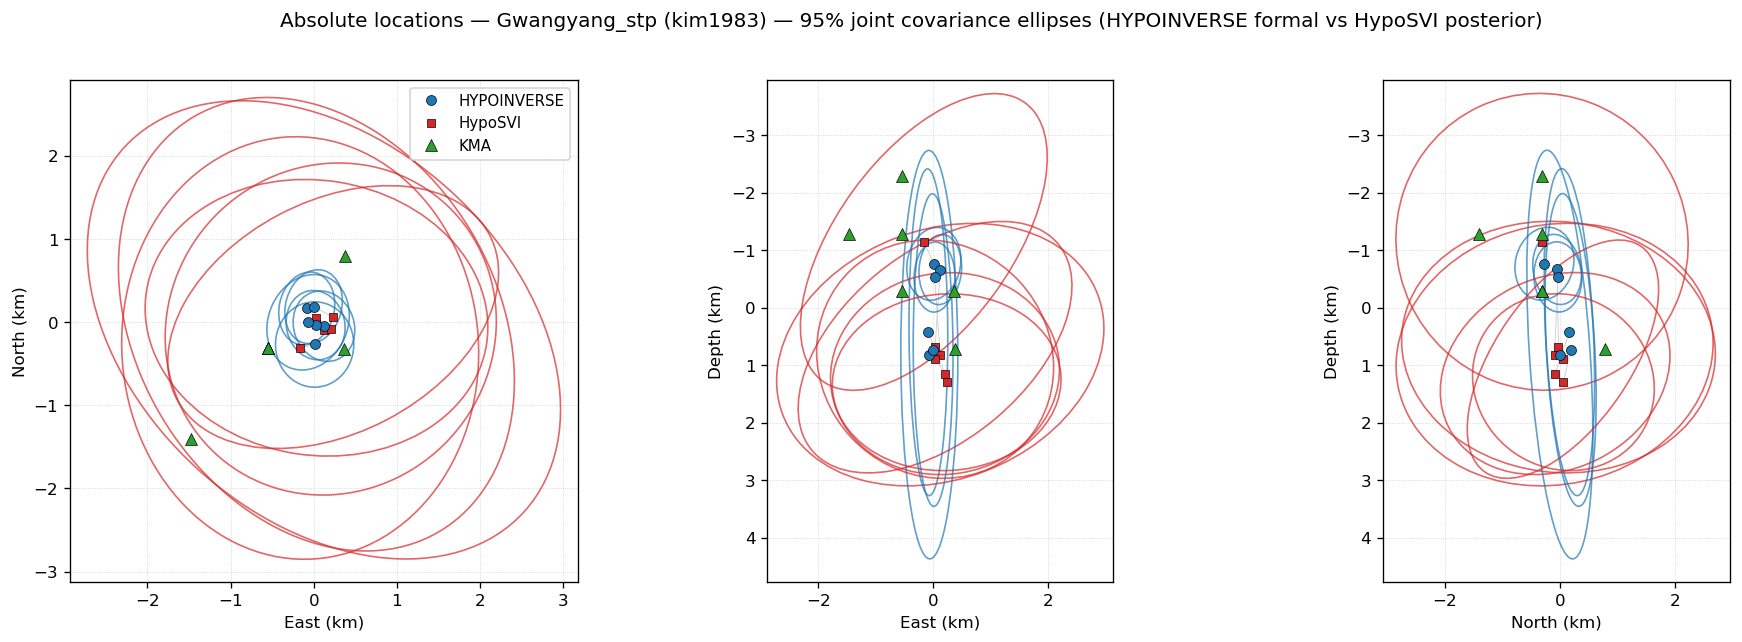

In [4]:
CONF = 0.95   # confidence level for ALL ellipses (both locators, same 95% joint scale)

# Per-plane 2x2 covariance (km^2) from a full covariance frame carrying
# cov_ee,cov_nn,cov_en,cov_zz,cov_ez,cov_nz (E=East, N=North, Z=depth).
_PLANE = {"EN": ("cov_ee", "cov_en", "cov_nn"),
          "EZ": ("cov_ee", "cov_ez", "cov_zz"),
          "NZ": ("cov_nn", "cov_nz", "cov_zz")}

def plane_ell(frame, i, plane, conf=CONF):
    # Oriented (semi-major, semi-minor, angle_deg) ellipse for one plane, or None.
    if i not in frame.index: return None
    r = frame.loc[i]; kxx, kxy, kyy = _PLANE[plane]
    if any(c not in frame.columns for c in (kxx, kxy, kyy)): return None
    a, b, ang = hyp_prt.error_ellipse(float(r[kxx]), float(r[kxy]), float(r[kyy]), conf)
    return None if np.isnan(a) else (a, b, ang)

def draw_ell(ax, x, y, ell, color):
    if ell:
        ax.add_patch(Ellipse((x, y), 2*ell[0], 2*ell[1], angle=ell[2],
                             fill=False, ec=color, lw=1.0, alpha=0.7, zorder=2))

fig, ax = plt.subplots(1, 3, figsize=(16, 5.2), dpi=120)
PLOTS = [(eH, nH, eS, nS, eK, nK, "East (km)",  "North (km)", "EN", False),
         (eH, zH, eS, zS, eK, zK, "East (km)",  "Depth (km)", "EZ", True),
         (nH, zH, nS, zS, nK, zK, "North (km)", "Depth (km)", "NZ", True)]
for j, (xH, yH, xS, yS, xK, yK, xl, yl, plane, inv) in enumerate(PLOTS):
    a = ax[j]
    for k in range(len(ids)):
        a.plot([xH[k], xS[k]], [yH[k], yS[k]], "-", c="0.8", lw=0.5, zorder=0)
    for k, i in enumerate(ids):
        draw_ell(a, xH[k], yH[k], plane_ell(PRT, i, plane),    "tab:blue")   # HYPOINVERSE (formal)
        draw_ell(a, xS[k], yS[k], plane_ell(SVICOV, i, plane), "tab:red")    # HypoSVI (posterior)
    a.plot(xH, yH, "o", ms=6, color="tab:blue", mec="k", mew=0.4, label="HYPOINVERSE", zorder=4)
    a.plot(xS, yS, "s", ms=5, color="tab:red", mec="k", mew=0.4, label="HypoSVI", zorder=3)
    a.plot(xK, yK, "^", ms=7, color="tab:green", mec="k", mew=0.4, label="KMA", zorder=5)
    a.set_xlabel(xl); a.set_ylabel(yl); a.set_aspect("equal", "box")
    a.grid(True, ls=":", lw=0.5, alpha=0.6)
    if inv: a.invert_yaxis()
ax[0].legend(fontsize=9, loc="best")
fig.suptitle(f"Absolute locations — {cfg.region} ({VELMODEL}) — {int(CONF*100)}% joint covariance ellipses "
             f"(HYPOINVERSE formal vs HypoSVI posterior)", y=1.02)
fig.tight_layout(); plt.show()

## 2. Pairwise location differences (m)

Horizontal `sqrt(dE^2+dN^2)` and depth `|dZ|`, in metres, for every matched event.

In [5]:
def _pair(EA, NA, ZA, EB, NB, ZB):
    return (np.hypot(EA-EB, NA-NB)*1000.0, np.abs(ZA-ZB)*1000.0)

dH_hs, dZ_hs = _pair(EH, NH, ZH, ES, NS, ZS)       # HINV vs SVI
dH_hk, dZ_hk = _pair(EH, NH, ZH, EK, NK, ZK)       # HINV vs KMA
dH_sk, dZ_sk = _pair(ES, NS, ZS, EK, NK, ZK)       # SVI  vs KMA

T = pd.DataFrame(dict(
    id=ids, event_id=[id2eid.get(i) for i in ids],
    HINV_dep=np.round(ZH,2), SVI_dep=np.round(ZS,2), KMA_dep=np.round(ZK,2),
    dHoriz_HINV_SVI_m=np.round(dH_hs,1), dDepth_HINV_SVI_m=np.round(dZ_hs,1),
    dHoriz_HINV_KMA_m=np.round(dH_hk,1), dDepth_HINV_KMA_m=np.round(dZ_hk,1),
    dHoriz_SVI_KMA_m =np.round(dH_sk,1), dDepth_SVI_KMA_m =np.round(dZ_sk,1),
))
display(T)
def _med(x):
    x = np.asarray(x, float); x = x[np.isfinite(x)]
    return np.median(x) if len(x) else np.nan
print(f"MEDIAN horizontal diff (m):  HINV-SVI {_med(dH_hs):6.0f} | HINV-KMA {_med(dH_hk):6.0f} | SVI-KMA {_med(dH_sk):6.0f}")
print(f"MEDIAN depth diff      (m):  HINV-SVI {_med(dZ_hs):6.0f} | HINV-KMA {_med(dZ_hk):6.0f} | SVI-KMA {_med(dZ_sk):6.0f}")

,id,event_id,HINV_dep,SVI_dep,KMA_dep,dHoriz_HINV_SVI_m,dDepth_HINV_SVI_m,dHoriz_HINV_KMA_m,dDepth_HINV_KMA_m,dHoriz_SVI_KMA_m,dDepth_SVI_KMA_m
0,200000,20210720161418,14.52,14.14,13.0,179.0,380.0,558.5,1520.0,383.3,1140.0
1,200001,20210827002315,14.62,15.97,14.0,93.9,1350.0,717.4,620.0,643.2,1970.0
2,200002,20210827220322,14.75,16.10,15.0,114.7,1350.0,444.0,250.0,331.6,1100.0
3,200003,20210828133410,15.71,16.43,16.0,380.6,720.0,779.7,290.0,891.5,430.0
4,200004,20210828133922,16.10,16.18,14.0,114.7,80.0,1985.0,2100.0,2095.1,2180.0
5,200005,20210828234556,16.02,16.58,15.0,266.8,560.0,734.2,1020.0,862.6,1580.0


MEDIAN horizontal diff (m):  HINV-SVI    147 | HINV-KMA    726 | SVI-KMA    753
MEDIAN depth diff      (m):  HINV-SVI    640 | HINV-KMA    820 | SVI-KMA   1360


## 3. Uncertainty comparison

Per-event reported uncertainty (95%): HYPOINVERSE from `.prt` covariance (horizontal = 95% joint
semi-major; depth = 1.96 sigma_z), HypoSVI posterior ERH/ERZ, plus RMS, GAP, NUM. KMA = N/A.

In [6]:
def _smaj95(cov_frame, sum_frame, i):
    # 95% joint horizontal semi-major (km); fall back to scalar ERH x 2.448 if no covariance.
    e = plane_ell(cov_frame, i, "EN")
    if e: return e[0]
    return sum_frame.loc[i].erh * hyp_prt.K_HORIZ_95_JOINT if i in sum_frame.index else np.nan

def _dz95(cov_frame, sum_frame, i):
    # 95% 1-D depth half-width = 1.96 sqrt(cov_zz); fall back to scalar ERZ x 1.96.
    if i in cov_frame.index and "cov_zz" in cov_frame.columns and not np.isnan(cov_frame.loc[i].cov_zz):
        return hyp_prt.K_1D_95 * float(np.sqrt(max(cov_frame.loc[i].cov_zz, 0.0)))
    return sum_frame.loc[i].erz * hyp_prt.K_1D_95 if i in sum_frame.index else np.nan

U = pd.DataFrame([dict(
    id=i, event_id=id2eid.get(i),
    HINV_erh95_km=round(_smaj95(PRT, HINV, i),3), HINV_erz95_km=round(_dz95(PRT, HINV, i),3),
    HINV_rms_s=round(float(HINV.loc[i].rms),3), HINV_gap=int(HINV.loc[i].gap), HINV_num=int(HINV.loc[i].num),
    SVI_erh95_km=round(_smaj95(SVICOV, SVI, i),3), SVI_erz95_km=round(_dz95(SVICOV, SVI, i),3),
    SVI_rms_s=round(float(SVI.loc[i].rms),3), SVI_gap=int(SVI.loc[i].gap), SVI_num=int(SVI.loc[i].num),
) for i in ids])
display(U)
for c in ["HINV_erh95_km","HINV_erz95_km","SVI_erh95_km","SVI_erz95_km"]:
    v = pd.to_numeric(U[c], errors="coerce"); print(f"  median {c:16s} = {v.median():.3f} km")
print("\nBoth erh95 = 95% joint horizontal semi-major from the covariance ellipse (HINV .prt formal,")
print("SVI SVGD posterior). HypoSVI's posterior is wider than HYPOINVERSE's formal LSQ error, as expected.")
print("HINV_num vs SVI_num differ slightly — HYPOINVERSE down-weights/rejects far phases; same SAC picks.")

,id,event_id,HINV_erh95_km,HINV_erz95_km,HINV_rms_s,HINV_gap,HINV_num,SVI_erh95_km,SVI_erz95_km,SVI_rms_s,SVI_gap,SVI_num
0,200000,20210720161418,0.513,0.507,0.21,39,69,2.542,2.066,0.35,39,72
1,200001,20210827002315,0.432,0.488,0.20,35,96,2.899,1.751,0.26,35,99
2,200002,20210827220322,0.420,0.488,0.18,35,98,3.253,1.828,0.24,35,99
3,200003,20210828133410,0.442,2.276,0.16,44,101,2.042,1.406,0.35,44,102
4,200004,20210828133922,0.589,2.844,0.18,76,45,2.070,1.659,1.21,75,47
5,200005,20210828234556,0.452,2.177,0.17,44,99,2.124,1.231,0.16,44,101


  median HINV_erh95_km    = 0.447 km
  median HINV_erz95_km    = 1.342 km
  median SVI_erh95_km     = 2.333 km
  median SVI_erz95_km     = 1.705 km

Both erh95 = 95% joint horizontal semi-major from the covariance ellipse (HINV .prt formal,
SVI SVGD posterior). HypoSVI's posterior is wider than HYPOINVERSE's formal LSQ error, as expected.
HINV_num vs SVI_num differ slightly — HYPOINVERSE down-weights/rejects far phases; same SAC picks.


## 4. Takeaway

- **HYPOINVERSE vs HypoSVI** — both locate the *same picks* with the *same crustal model*; their
  difference is the locator-method difference (least-squares vs SVGD posterior mode). A few hundred
  metres horizontally is expected for well-recorded events.
- **vs KMA** — KMA uses its own operational picks/locator; differences reflect picking + method +
  velocity-model. KMA depths are often loosely constrained (sometimes fixed), so depth differences
  are typically larger than horizontal.
- **Uncertainties** — HYPOINVERSE's formal 95% (from the `.prt` covariance) and HypoSVI's posterior
  95% are now on the same footing; HypoSVI's posterior is usually wider where depth is poorly
  constrained — an honest reflection of the data geometry.